# Deep learning models for arrhythmia detection and diagnosis

## Initialisation

In [6]:
# Imports
import os
from os.path import join as osj
import pandas as pd
import numpy as np
import torch
import wfdb
import pywt
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from scipy.signal import butter, filtfilt, iirnotch

# Directory where the dataset is stored
dataset_directory = 'mit-bih-arrhythmia-database-1.0.0/'

# Get an array of all ids
record_ids = pd.read_csv('mit-bih-arrhythmia-database-1.0.0/RECORDS', header=None).to_numpy().reshape(-1)

# Initialise dictionaries to store data
lead1 = {}
lead2 = {}
annotations = {}

# Load ECG signals and annotations
for id in record_ids:
    signals, info = wfdb.io.rdsamp(osj(dataset_directory, str(id)))
    annotation = wfdb.rdann(dataset_directory + str(id), "atr")
    lead1[id] = signals[:, 0]
    lead2[id] = signals[:, 1]
    annotations[id] = annotation
            

## Data Preprocessing

### Define Preprocessing Functions

In [21]:
# Filtering 
def wavelet_denoise(signal, wavelet='db4', level=5):
    coeffs = pywt.wavedec(signal, wavelet, level=level)
    coeffs[1:] = [pywt.threshold(c, np.std(c) * 0.4, mode='soft') for c in coeffs[1:]]
    return pywt.waverec(coeffs, wavelet)

def notch_filter(signal, freq=50, fs=360, quality_factor=30):
    nyquist = 0.5 * fs
    w0 = freq / nyquist
    b, a = iirnotch(w0, quality_factor)
    return filtfilt(b, a, signal)

# Z-score normalization (Standardisation) function
def normalize_zscore(data):
    mean_val = np.mean(data)
    std_val = np.std(data)
    return (data - mean_val) / std_val

# Segmentation : based around the midpoints of R-peaks contained in the file.
def segmentation(lead, annotation):  
    r_peaks = annotation.sample
    r_labels = annotation.symbol
    
    segments = []
    labels = []
    
    # Ensure enough R-peaks to segment
    if len(r_peaks) < 2:
        return [], []
    
    # Compute midpoints between R-peaks
    midpoints = [(r_peaks[i] + r_peaks[i + 1]) // 2 for i in range(len(r_peaks) - 1)]
    
    # Handle all beats with a midpoint either side (not first and last)
    for i in range(1, len(midpoints)):
        start = midpoints[i - 1]
        end = midpoints[i]
        segment = lead[start:end]
        label = r_labels[i]  # Label corresponding to the center R-peak
        segments.append(segment)
        labels.append(label)
    
    # Handle the first beat 
    first_segment = lead[:midpoints[1]]
    segments.insert(0, first_segment)
    labels.insert(0, r_labels[0])
    
    # Handle the last beat
    if midpoints[-1] < len(lead):
        last_segment = lead[midpoints[-1]:]
        segments.append(last_segment)
        labels.append(r_labels[-1])
    
    return segments, labels

### Segmentation

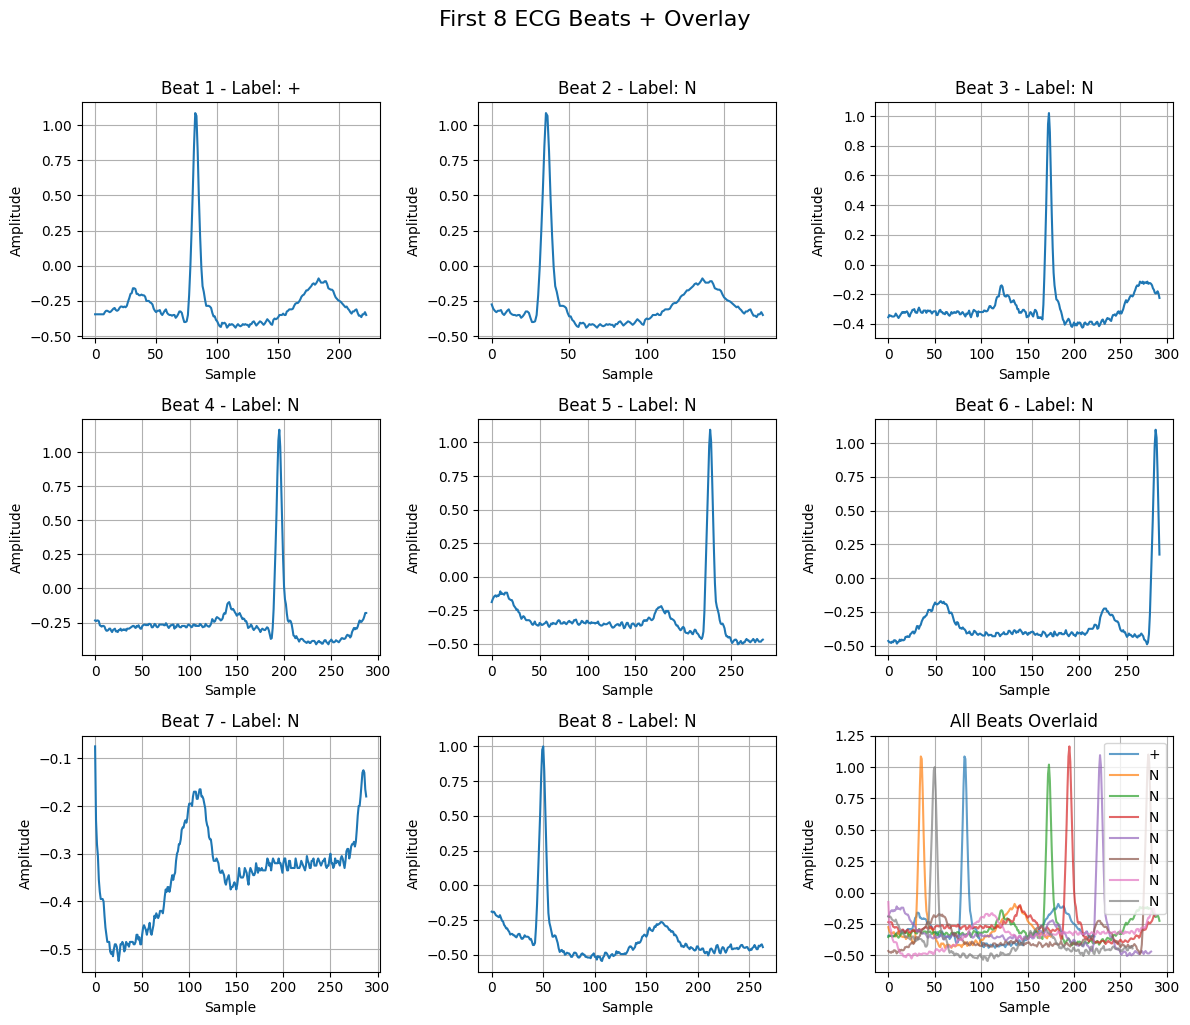

In [27]:
beats, labels = segmentation(lead1[101], annotations[100])

plt.figure(figsize=(12, 10))
num_beats = 8
for i in range(num_beats):
    plt.subplot(3, 3, i+1)
    plt.plot(beats[i], label=f'Label: {labels[i]}')
    plt.title(f'Beat {i+1} - Label: {labels[i]}')
    plt.xlabel('Sample')
    plt.ylabel('Amplitude')
    plt.grid(True)
    plt.tight_layout()

# Plot all beats together in 9th subplot
plt.subplot(3, 3, 9)
for i in range(num_beats):
    plt.plot(beats[i], label=f'{labels[i]}', alpha=0.7)
plt.title('All Beats Overlaid')
plt.xlabel('Sample')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)

plt.suptitle('First 8 ECG Beats + Overlay', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()
     

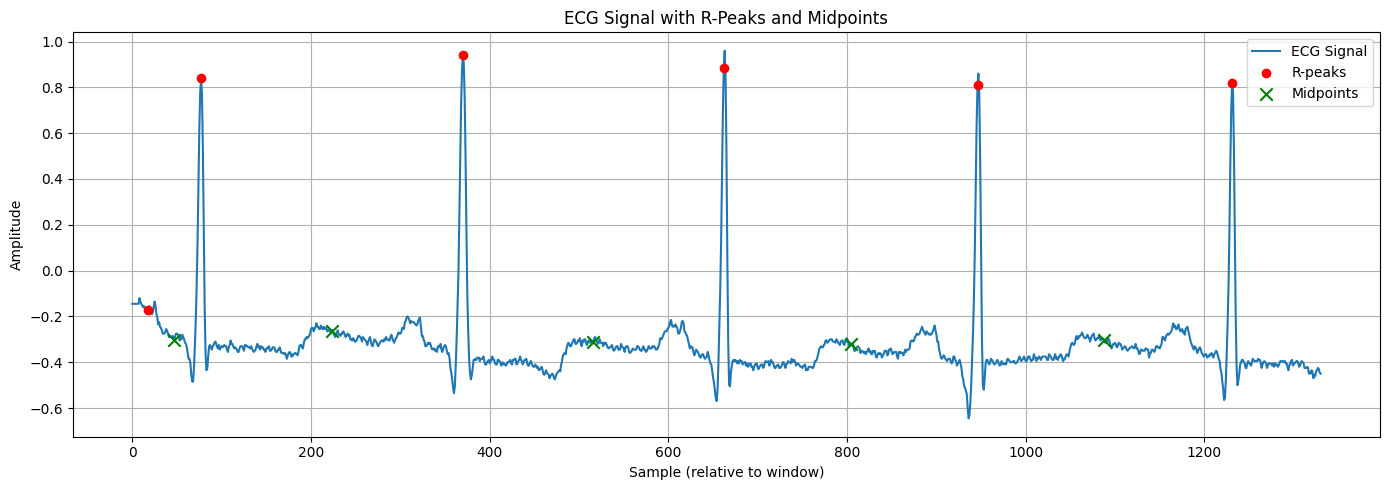

In [29]:
# Number of beats to visualize
num_beats = 5

# Get R-peaks and symbols from annotation
r_peaks = annotations[100].sample
r_labels = annotations[100].symbol

# Select the first (num_beats + 1) R-peaks to define 5 complete beat intervals
selected_r = r_peaks[:num_beats + 1]

# Compute midpoints between successive R-peaks
midpoints = [(selected_r[i] + selected_r[i + 1]) // 2 for i in range(num_beats)]

# Define the signal segment for plotting
start_idx = max(0, selected_r[0] - 100)
end_idx = min(len(lead1[100]), selected_r[num_beats] + 100)
segment = lead1[100][start_idx:end_idx]

# Adjust R-peak and midpoint indices relative to the segment
adjusted_r = [r - start_idx for r in selected_r if start_idx <= r < end_idx]
adjusted_mid = [m - start_idx for m in midpoints if start_idx <= m < end_idx]

# Get the y-values from the lead signal for those points
r_y = [lead1[100][r] for r in selected_r if start_idx <= r < end_idx]
mid_y = [lead1[100][m] for m in midpoints if start_idx <= m < end_idx]

# Plot the ECG segment
plt.figure(figsize=(14, 5))
plt.plot(segment, label='ECG Signal')
plt.scatter(adjusted_r, r_y, color='red', label='R-peaks', zorder=3)
plt.scatter(adjusted_mid, mid_y, color='green', marker='x', s=80, label='Midpoints', zorder=3)
plt.title('ECG Signal with R-Peaks and Midpoints')
plt.xlabel('Sample (relative to window)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## Models

### Beat Classifier

In [ ]:
class BeatClassifier(nn.Module):
    def __init__(self, input_size, num_classes):
        super(BeatClassifier, self).__init__()
        
        # Feature extraction layers
        self.feature_extractor = nn.Sequential(
            nn.Conv1d(in_channels=1, out_channels=64, kernel_size=5, stride=1, padding=2),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2, stride=2),
            nn.Conv1d(in_channels=64, out_channels=128, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2, stride=2)
        )
        
        # Fully connected layers for classification
        self.classifier = nn.Sequential(
            nn.Linear(128 * (input_size // 4), 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )
    
    def forward(self, x):
        x = self.feature_extractor(x)
        x = x.view(x.size(0), -1)  # Flatten
        x = self.classifier(x)
        return x

### Signal Classifier

In [ ]:
class SignalClassifier(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes):
        super(SignalClassifier, self).__init__()
        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size, num_layers=num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, num_classes)
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x, _ = self.lstm(x)
        x = x[:, -1, :]  # Take the last time step output
        x = self.dropout(x)
        x = self.fc(x)
        return x
    
class SignalTransformer(nn.Module):
    def __init__(self, input_size=3, d_model=64, num_heads=4, num_layers=2, num_classes=5):
        super(SignalTransformer, self).__init__()
        
        # Positional Encoding
        self.positional_encoding = nn.Parameter(torch.zeros(1, 100, d_model))  # Max sequence length = 100
        
        # Transformer Encoder Layer
        self.encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=num_heads)
        self.transformer = nn.TransformerEncoder(self.encoder_layer, num_layers=num_layers)
        
        # Fully Connected Layer
        self.fc = nn.Linear(d_model, num_classes)
        self.softmax = nn.Softmax(dim=1)
        
    def forward(self, x):
        # x: Batch size x sequence length x input size
        x = x * np.sqrt(64)  # Scaling input (similar to Transformer)
        
        # Add positional encoding (optional)
        x = x + self.positional_encoding[:, :x.size(1), :]
        
        # Transformer expects input shape (seq_len, batch_size, input_size)
        x = x.permute(1, 0, 2)  # Shape: (sequence_length, batch_size, feature_size)
        
        # Pass through Transformer Encoder
        x = self.transformer(x)
        
        # Use the output of the last token
        x = x[-1, :, :]  # Only take the last token's output
        
        # Final classification
        x = self.fc(x)
        x = self.softmax(x)
        return x

### Transformer

## Training

In [ ]:
def train_model(model, dataloader, criterion, optimizer, device):
    model.train()
    total_loss, correct = 0, 0
    for inputs, labels in dataloader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        correct += (predicted == labels).sum().item()
    return total_loss / len(dataloader), correct / len(dataloader.dataset)

## Testing

In [ ]:
def evaluate_model(model, dataloader, device):
    model.eval()
    correct = 0
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            correct += (predicted == labels).sum().item()
    return correct / len(dataloader.dataset)

## Evaluation